# CardioIA Fase 2 — Classificação de texto

**Guilherme Yamada Dantas · RM 568506**

Pergunta: um classificador simples aprende os dois rótulos de uma pequena base sintética? Usamos TF-IDF e regressão logística, com grupos de cenários separados e uma referência majoritária. O objetivo é demonstrar um experimento auditável, não validar um produto médico.

## 1. Dados e protocolo

São 160 frases, 40 cenários e quatro paráfrases por cenário. Os rótulos foram elaborados para a simulação e não validados clinicamente. O sidecar registra grupo e hash de cada frase para impedir desalinhamento silencioso.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'assets/dados').is_dir(), 'Abra o notebook dentro do repositório.'
sys.path.insert(0, str(ROOT))
from src.classificacao import carregar_dados, separar_grupos, criar_pipeline, treinar_avaliar, prever_frase, auditoria_equidade
dados = carregar_dados()
display(dados.head())
display(dados.groupby("situacao").agg(frases=("frase", "size"), grupos=("grupo", "nunique")))

,frase_id,grupo,cenario,frase,situacao
0,f001,g01,Cenário sintético 01: cansaço leve que passou ...,"Sinto cansaço leve que passou após descansar, ...",baixo risco
1,f002,g01,Cenário sintético 01: cansaço leve que passou ...,"Depois da caminhada de ontem, comecei a aprese...",baixo risco
2,f003,g01,Cenário sintético 01: cansaço leve que passou ...,Meu relato é de cansaço leve que passou após d...,baixo risco
3,f004,g01,Cenário sintético 01: cansaço leve que passou ...,Percebi depois da caminhada de ontem que estav...,baixo risco
4,f005,g02,Cenário sintético 02: dor muscular leve no omb...,Sinto dor muscular leve no ombro ao mover o br...,baixo risco


,frases,grupos
situacao,,
alto risco,80,20
baixo risco,80,20


## 2. Separar antes de aprender

Divisão estratificada por grupo em 60% treino, 20% validação e 20% teste, seed 42. Paráfrases do mesmo cenário não atravessam partições. Isso não remove toda semelhança estilística entre cenários. Hiperparâmetros foram fixados antes de observar as métricas; a validação é reportada, sem busca de parâmetros.

In [2]:
particoes = separar_grupos(dados)
display(particoes.groupby("particao").agg(frases=("frase", "size"), grupos=("grupo", "nunique")))
assert particoes.groupby("grupo").particao.nunique().max() == 1
assert particoes.groupby("cenario").particao.nunique().max() == 1
print("Grupos e cenários disjuntos entre as partições.")

,frases,grupos
particao,,
teste,32,8
treino,96,24
validacao,32,8


Grupos e cenários disjuntos entre as partições.


## 3. Vetorizar e classificar

O `Pipeline` ajusta vocabulário e IDF apenas no treino. TF-IDF representa unigramas e bigramas; não removemos palavras como “não”. Regressão logística usa C=1, solver liblinear e no máximo 1.000 iterações. Preservar a negação no vetor não garante compreendê-la.

In [3]:
pipeline_explicado = criar_pipeline()
display(pipeline_explicado)
resultado = treinar_avaliar()
modelo = resultado["pipeline"]
metricas = resultado["metricas"]
print("Termos aprendidos somente no treino:", metricas["vocabulario_treino"])
display(metricas["versoes"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), strip_accents='unicode')),
                ('classificador',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

Termos aprendidos somente no treino: 590


{'python': '3.11.11', 'sklearn': '1.6.0', 'pandas': '2.3.3', 'numpy': '2.2.6'}

## 4. Avaliar contra uma referência simples

Acurácia é a proporção de acertos. Precisão, recall e F1 por classe mostram aspectos complementares. O baseline sempre prevê a classe majoritária do treino. Leia os números como desempenho no corpus sintético.

,partição,acurácia modelo,acurácia baseline
0,treino,1.00,0.5
1,validacao,0.75,0.5
2,teste,1.00,0.5


,precision,recall,f1-score,support
baixo risco,1.0,1.0,1.0,16.0
alto risco,1.0,1.0,1.0,16.0


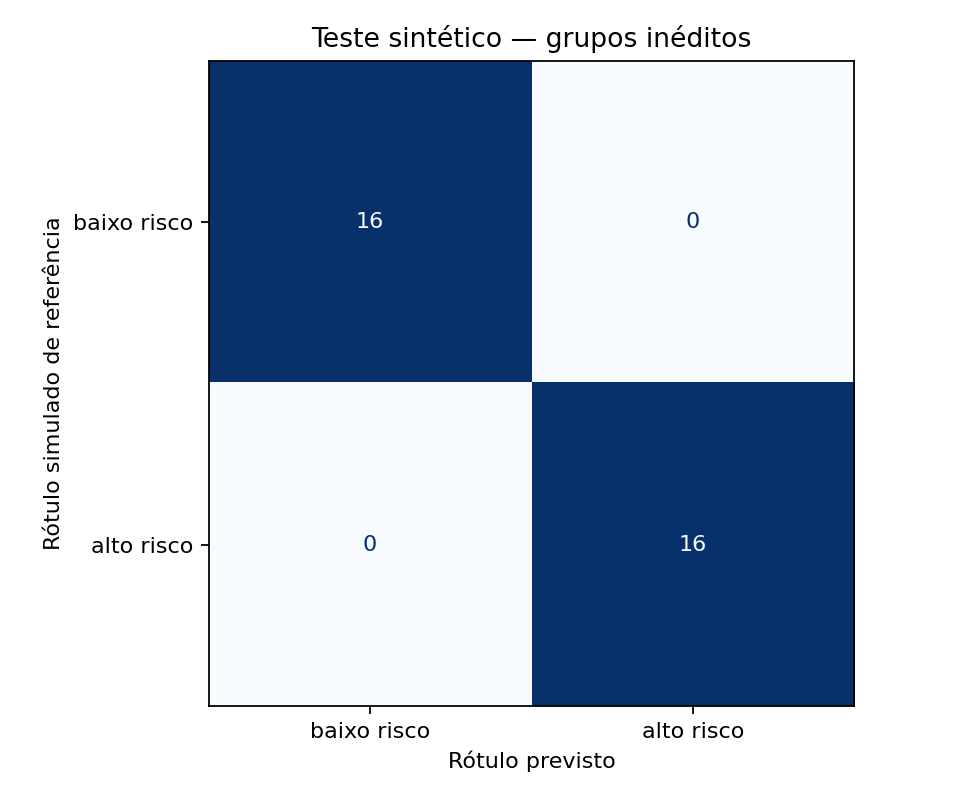

In [4]:
comparacao = pd.DataFrame([{
    "partição": p, "acurácia modelo": metricas["modelo"][p]["acuracia"],
    "acurácia baseline": metricas["baseline"][p]["acuracia"]
} for p in ["treino", "validacao", "teste"]])
display(comparacao)
teste = metricas["modelo"]["teste"]
display(pd.DataFrame({k: teste["por_classe"][k] for k in teste["ordem_rotulos"]}).T)
from IPython.display import Image
display(Image(filename=str(ROOT / "document/evidencias/matriz_confusao.png")))

## 5. Inspecionar todos os erros

Falso negativo aqui significa rótulo sintético alto risco previsto como baixo risco. Se não houver erros no teste, isso não significa ausência de falhas em outros textos.

In [5]:
previsoes = resultado["previsoes"]
erros = previsoes.loc[previsoes.erro]
print("Erros no teste:", len(erros))
print("Falsos negativos no teste:", metricas["falsos_negativos_teste"])
display(erros if len(erros) else previsoes.head(8))

Erros no teste: 0
Falsos negativos no teste: 0


,frase_id,grupo,frase,real,previsto,probabilidade_modelo,erro,falso_negativo
4,f005,g02,Sinto dor muscular leve no ombro ao mover o br...,baixo risco,baixo risco,0.585722,False,False
5,f006,g02,"Após carregar caixas ontem, comecei a apresent...",baixo risco,baixo risco,0.589638,False,False
6,f007,g02,Meu relato é de dor muscular leve no ombro ao ...,baixo risco,baixo risco,0.590499,False,False
7,f008,g02,Percebi após carregar caixas ontem que estava ...,baixo risco,baixo risco,0.597086,False,False
44,f045,g12,Sinto dor superficial no braço que aparece só ...,baixo risco,baixo risco,0.543883,False,False
45,f046,g12,"Desde uma pequena batida ontem, comecei a apre...",baixo risco,baixo risco,0.550471,False,False
46,f047,g12,Meu relato é de dor superficial no braço que a...,baixo risco,baixo risco,0.560294,False,False
47,f048,g12,Percebi desde uma pequena batida ontem que est...,baixo risco,baixo risco,0.560936,False,False


## 6. Desafiar a compreensão da linguagem

Esta sondagem foi criada após a primeira avaliação e não integra o teste reservado. Não foi usada para reajustar o modelo. Os pares abaixo examinam negação; não atribuímos a eles um diagnóstico nem um rótulo clínico verdadeiro. Uma previsão igual nos dois membros mostra que o modelo pode responder às palavras de sintomas sem distinguir a sua ausência.

In [6]:
desafios = ["Sinto dor no peito e suor frio.", "Não sinto dor no peito e não tenho suor frio.", "Sinto falta de ar.", "Não sinto falta de ar.", "xyzk qwrtyp"]
display(pd.DataFrame([{"frase": f, **prever_frase(f, modelo)} for f in desafios]))

,frase,rotulo,probabilidade_modelo,status
0,Sinto dor no peito e suor frio.,alto risco,0.707684,ok
1,Não sinto dor no peito e não tenho suor frio.,alto risco,0.762741,ok
2,Sinto falta de ar.,alto risco,0.650840,ok
3,Não sinto falta de ar.,alto risco,0.699049,ok
4,xyzk qwrtyp,None,NaN,fora_vocabulario


## 7. Sensibilidade a variações textuais

Comparamos três pares por eixo de gênero e idade. É uma sondagem pequena e sem desfechos clínicos. Não comprova equidade; idade pode ser um fator relevante em outros contextos.

In [7]:
auditoria = auditoria_equidade(modelo)
print(auditoria["natureza"])
display(pd.DataFrame(auditoria["pares"]))

Exploratório: 3 pares por eixo, sem inferência sobre equidade ou validade clínica. Idade pode ser clinicamente relevante; esta sondagem mede somente sensibilidade textual.


,eixo,frases,previsoes,mudou_rotulo,diferenca_probabilidade_classe_prevista
0,genero,"[Sou homem, sinto pressão intensa no peito e f...","[{'rotulo': 'alto risco', 'probabilidade_model...",False,0.0
1,genero,"[Sou homem, sinto dor leve no braço após exerc...","[{'rotulo': 'baixo risco', 'probabilidade_mode...",False,0.0
2,genero,"[Sou homem, não sinto dor no peito nem falta d...","[{'rotulo': 'alto risco', 'probabilidade_model...",False,0.0
3,idade,"[Tenho 25 anos, sinto pressão intensa no peito...","[{'rotulo': 'alto risco', 'probabilidade_model...",False,0.0
4,idade,"[Tenho 25 anos, sinto dor leve no braço após e...","[{'rotulo': 'baixo risco', 'probabilidade_mode...",False,0.0
5,idade,"[Tenho 25 anos, não sinto dor no peito nem fal...","[{'rotulo': 'alto risco', 'probabilidade_model...",False,0.0


## 8. Conclusão e limites

Um resultado perfeito nesta base revela também sua facilidade: os textos têm padrões recorrentes e vêm de um mesmo processo de autoria. Há somente oito grupos no teste, e as quatro paráfrases de cada grupo não são observações independentes. Não foi calculado um intervalo que presumisse essa independência.

Os contraexemplos expõem fragilidade de negação mesmo com boas métricas internas. Próximos experimentos precisam de um conjunto independente mais diverso, rótulos revisados e avaliação adequada ao uso pretendido. Qualquer alteração orientada por estes testes exigirá um novo teste final antes de alegar generalização inédita.

**Referência técnica:** [Scikit-learn — prevenção de vazamento de dados](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage). Veja `document/metodologia.md` e os CSVs de partições/previsões para auditoria.